***NITHISHM2410_driver drowsiness detection\***   

출처: NITHISHM2410, Driver Drowsiness Detection, GitHub.
github.com/NITHISHM2410/driver-drowsiness-detection

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
ZIP_PATH = "/content/drive/MyDrive/BOAZ_27th_Base/미프1/driver-drowsiness-detection-main.zip"

In [3]:
import os

print(os.path.exists(ZIP_PATH))

True


In [4]:
import zipfile
import os

# 파일명 확인
ZIP_PATH = "/content/drive/MyDrive/BOAZ_27th_Base/미프1/driver-drowsiness-detection-main.zip"
EXTRACT_PATH = "/content/driver_project"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("압축 해제 완료!")

압축 해제 완료!


In [5]:
!find /content/driver_project -maxdepth 3 -type f

/content/driver_project/driver-drowsiness-detection-main/README.md


In [6]:
PROJECT_ROOT = "/content/driver_project/driver-drowsiness-detection-main"

!find "$PROJECT_ROOT" -maxdepth 4 -type f

/content/driver_project/driver-drowsiness-detection-main/README.md
/content/driver_project/driver-drowsiness-detection-main/Driver_Drowsiness_Detection/usage/detector.py
/content/driver_project/driver-drowsiness-detection-main/Driver_Drowsiness_Detection/usage/model
/content/driver_project/driver-drowsiness-detection-main/Driver_Drowsiness_Detection/NoteBooks/results/driver_drowsiness_detection_testing.ipynb
/content/driver_project/driver-drowsiness-detection-main/Driver_Drowsiness_Detection/NoteBooks/train/driver_drowsiness_detection_locating_eye.ipynb
/content/driver_project/driver-drowsiness-detection-main/Driver_Drowsiness_Detection/NoteBooks/train/driver_drowsiness_detection_yawn.ipynb
/content/driver_project/driver-drowsiness-detection-main/Driver_Drowsiness_Detection/NoteBooks/train/driver_drowsiness_detection_eye.ipynb


- 데이터셋 다운로드

In [7]:
!pip -q install kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download(
    "serenaraju/yawn-eye-dataset-new"
)

print("Dataset path:")
print(dataset_path)

100%|██████████| 161M/161M [00:00<00:00, 205MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1


In [8]:
#데이터 구조 확인
import os

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)

    if level <= 3:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for f in files[:5]:
            print(f"{indent}    {f}")

1/
    dataset_new/
        train/
            no_yawn/
                379.jpg
                1500.jpg
                648.jpg
                2290.jpg
                1864.jpg
            yawn/
                200.jpg
                69.jpg
                491.jpg
                648.jpg
                356.jpg
            Open/
                _528.jpg
                _234.jpg
                _657.jpg
                _646.jpg
                _635.jpg
            Closed/
                _528.jpg
                _234.jpg
                _657.jpg
                _646.jpg
                _635.jpg
        test/
            no_yawn/
                2110.jpg
                1452.jpg
                1096.jpg
                461.jpg
                610.jpg
            yawn/
                379.jpg
                122.jpg
                319.jpg
                455.jpg
                676.jpg
            Open/
                _451.jpg
                _32.jpg
                _64.jpg
         

In [13]:
import os
import glob

dataset_dirs = glob.glob(
    dataset_path + "/**/dataset_new",
    recursive=True
)

print("찾은 dataset_new:", dataset_dirs)

DATA_DIR = dataset_dirs[0]

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("TRAIN:", TRAIN_DIR)
print("TEST :", TEST_DIR)

print("\nTrain classes:", os.listdir(TRAIN_DIR))
print("Test classes :", os.listdir(TEST_DIR))

찾은 dataset_new: ['/root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new']
TRAIN: /root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new/train
TEST : /root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new/test

Train classes: ['no_yawn', 'yawn', 'Open', 'Closed']
Test classes : ['no_yawn', 'yawn', 'Open', 'Closed']


In [14]:
for split_dir in [TRAIN_DIR, TEST_DIR]:

    print("\n", split_dir)

    for cls in ["Closed", "Open", "no_yawn", "yawn"]:

        path = os.path.join(split_dir, cls)

        files = glob.glob(path + "/*")

        print(
            f"{cls:10s}: {len(files)} images"
        )


 /root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new/train
Closed    : 617 images
Open      : 617 images
no_yawn   : 616 images
yawn      : 617 images

 /root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new/test
Closed    : 109 images
Open      : 109 images
no_yawn   : 109 images
yawn      : 106 images


- 원본 Eye 학습 코드

In [9]:
import json

BASE = "/content/driver_project/driver-drowsiness-detection-main/Driver_Drowsiness_Detection"

EYE_NB = f"{BASE}/NoteBooks/train/driver_drowsiness_detection_eye.ipynb"

with open(EYE_NB, "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        print(f"\n===== CELL {i} =====")
        print("".join(cell["source"]))


===== CELL 2 =====
import numpy as np
import pandas as pd
import tensorflow as tf
tf.random.set_seed(42)
import matplotlib.pyplot as plt
from glob import glob
import cv2
import os
import shutil
import random
import math
import tensorflow_datasets as tfds

===== CELL 4 =====
from tensorflow.python import keras
print(keras.__version__)

===== CELL 6 =====
!mkdir images

===== CELL 8 =====
def _bytes_feature(value):
    if isinstance(value, type(tf.constant(0))):
        value = value.numpy()
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

===== CELL 10 =====
def serialize_example(image,label):
    feature = {
        'image':tf.train.Feature(bytes_list=tf.train.BytesList(value=[image])),
        'label':_bytes_feature(tf.io.serialize_tensor(label))
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()


===== CELL 12 =====
def tf_writer(op_path,filelist):
    classes=['Closed','Open']
    with 

- Yawn 학습 코드

In [10]:
YAWN_NB = f"{BASE}/NoteBooks/train/driver_drowsiness_detection_yawn.ipynb"

with open(YAWN_NB, "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        print(f"\n===== CELL {i} =====")
        print("".join(cell["source"]))


===== CELL 0 =====
from google.colab import drive
drive.mount('/content/drive')

===== CELL 1 =====
import numpy as np
import pandas as pd
import tensorflow as tf
tf.random.set_seed(42)
import matplotlib.pyplot as plt
from distutils.dir_util import copy_tree
from glob import glob
import PIL
from PIL import Image
import cv2
import os
import shutil
import random
import math
import tensorflow_datasets as tfds

===== CELL 4 =====
loaded = tf.keras.models.load_model("/content/drive/MyDrive/yawn_md.h5")

===== CELL 5 =====
for i in glob("/content/images/*"):
    im = plt.imread(i)
    plt.imshow(im)
    img = tf.expand_dims(im,axis = 0)
    img = tf.image.resize(img,(256,256))
    if np.argmax(np.squeeze(np.round(loaded(img)))) == 0:
        print("Prediction : Yawn")
    else:
        print("Prediction : Not Yawning")
    plt.show()


- 학습 및 결과 확인을 위한 패키지 설치

In [11]:
!pip -q install kagglehub mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.5 MB/s eta 0:00:00


In [12]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


- Eye 모델 데이터 준비

In [15]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

In [16]:
eye_train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=["Closed", "Open"],
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

eye_val = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=["Closed", "Open"],
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1234 files belonging to 2 classes.
Using 988 files for training.
Found 1234 files belonging to 2 classes.
Using 246 files for validation.


In [17]:
def build_eye_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(256, 256, 3)),

        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.RandomFlip("horizontal"),

        tf.keras.layers.RandomRotation(
            0.4,
            fill_mode="reflect",
            interpolation="bilinear"
        ),

        tf.keras.layers.Conv2D(
            32, 3,
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            32, 3,
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            32, 3,
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            128,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            2,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [20]:
eye_model = build_eye_model()

eye_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,178 (14.14 MB)

 Trainable params: 3,706,178 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Eye 모델 학습
eye_callback = tf.keras.callbacks.ModelCheckpoint(
    "/content/eye_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [22]:
eye_history = eye_model.fit(
    eye_train,
    validation_data=eye_val,
    epochs=10,
    callbacks=[eye_callback]
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.6518 - loss: 0.6341 - val_accuracy: 0.8821 - val_loss: 0.3372
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.8937 - loss: 0.2978 - val_accuracy: 0.8577 - val_loss: 0.3495
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.8998 - loss: 0.2542 - val_accuracy: 0.8862 - val_loss: 0.2817
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9170 - loss: 0.2383 - val_accuracy: 0.8821 - val_loss: 0.3181
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9211 - loss: 0.2251 - val_accuracy: 0.9065 - val_loss: 0.2248
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.9231 - loss: 0.2028 - val_accuracy: 0.9106 - val_loss: 0.2267
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9281 - loss: 0.1791 - val_accuracy: 0.8943 - val_loss: 0.2782
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9251 - loss: 0.1854 - val_accuracy: 0.9065 

In [23]:
eye_model = tf.keras.models.load_model(
    "/content/eye_model.keras"
)

print("Eye model 준비 완료")

Eye model 준비 완료


- Yawn 데이터 준비

In [24]:
yawn_train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=["yawn", "no_yawn"],
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

yawn_val = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=["yawn", "no_yawn"],
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1233 files belonging to 2 classes.
Using 987 files for training.
Found 1233 files belonging to 2 classes.
Using 246 files for validation.


- Yawn CNN 생성

In [25]:
def build_yawn_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(256, 256, 3)),

        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.RandomFlip("horizontal"),

        tf.keras.layers.RandomRotation(0.2),

        tf.keras.layers.Conv2D(
            32, 3,
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            32, 3,
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            32, 3,
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            128,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            2,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [26]:
yawn_model = build_yawn_model()

yawn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,178 (14.14 MB)

 Trainable params: 3,706,178 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

- Yawn 모델 학습

In [27]:
yawn_callback = tf.keras.callbacks.ModelCheckpoint(
    "/content/yawn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [28]:
yawn_history = yawn_model.fit(
    yawn_train,
    validation_data=yawn_val,
    epochs=10,
    callbacks=[yawn_callback]
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.5329 - loss: 0.7799 - val_accuracy: 0.4472 - val_loss: 0.6902
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.6069 - loss: 0.6536 - val_accuracy: 0.6504 - val_loss: 0.6244
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.6322 - loss: 0.6288 - val_accuracy: 0.6545 - val_loss: 0.6194
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.6393 - loss: 0.6047 - val_accuracy: 0.5122 - val_loss: 0.7408
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.6484 - loss: 0.5873 - val_accuracy: 0.5813 - val_loss: 0.6629
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.6849 - loss: 0.5728 - val_accuracy: 0.6626 - val_loss: 0.6017
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.6849 - loss: 0.5618 - val_accuracy: 0.5163 - val_loss: 0.7422
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.6900 - loss: 0.5517 - val_accuracy: 0.6220

In [29]:
yawn_model = tf.keras.models.load_model(
    "/content/yawn_model.keras"
)

print("Yawn model 준비 완료")

Yawn model 준비 완료


- detector.py 연결 전 각 모델 테스트

실제: Closed
예측: Closed
확률: [0.9641982  0.03580183]


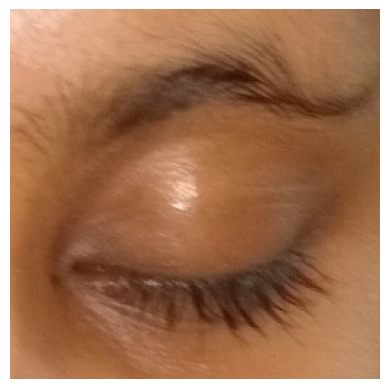

In [30]:
for images, labels in eye_val.take(1):

    pred = eye_model.predict(images[:1], verbose=0)

    pred_class = np.argmax(pred[0])
    true_class = np.argmax(labels[0])

    names = ["Closed", "Open"]

    print("실제:", names[true_class])
    print("예측:", names[pred_class])
    print("확률:", pred[0])

    plt.imshow(images[0].numpy().astype("uint8"))
    plt.axis("off")
    plt.show()

실제: Yawn
예측: No Yawn
확률: [0.20525959 0.7947404 ]


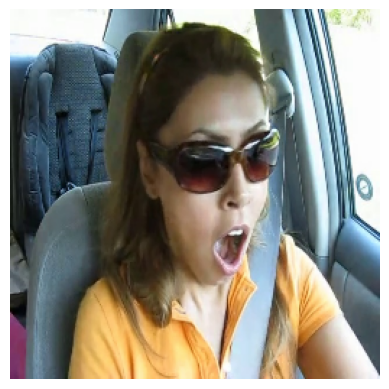

In [31]:
for images, labels in yawn_val.take(1):

    pred = yawn_model.predict(
        images[:1],
        verbose=0
    )

    pred_class = np.argmax(pred[0])
    true_class = np.argmax(labels[0])

    names = ["Yawn", "No Yawn"]

    print("실제:", names[true_class])
    print("예측:", names[pred_class])
    print("확률:", pred[0])

    plt.imshow(
        images[0].numpy().astype("uint8")
    )

    plt.axis("off")
    plt.show()

- 두 모델 결합 - detector.py

In [32]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from mtcnn import MTCNN


class Drowsiness_Detector:

    def __init__(self, list_models):

        # 원본 코드 오류 수정
        # list_models를 먼저 저장해야 함
        self.list_models = list_models

        self.detector = MTCNN()

        self.models = self.get_models_ready()


    def get_models_ready(self):

        eye_model = tf.keras.models.load_model(
            self.list_models[0]
        )

        yawn_model = tf.keras.models.load_model(
            self.list_models[1]
        )

        return eye_model, yawn_model


    @staticmethod
    def sharpen(img):

        kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])

        return cv2.filter2D(
            src=img,
            ddepth=-1,
            kernel=kernel
        )


    def extract_eyes(self, image):

        # MTCNN은 RGB 입력 사용
        rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        results = self.detector.detect_faces(rgb)

        if len(results) == 0:
            return None

        face = results[0]

        keypoints = face["keypoints"]

        left_eye = keypoints["left_eye"]
        right_eye = keypoints["right_eye"]

        h, w = image.shape[:2]

        # 얼굴 크기를 기준으로 eye crop 크기 결정
        face_width = face["box"][2]

        eye_size = max(
            int(face_width * 0.22),
            20
        )


        def crop_eye(center):

            x, y = center

            x1 = max(
                int(x - eye_size),
                0
            )

            y1 = max(
                int(y - eye_size),
                0
            )

            x2 = min(
                int(x + eye_size),
                w
            )

            y2 = min(
                int(y + eye_size),
                h
            )

            eye = image[
                y1:y2,
                x1:x2
            ]

            if eye.size == 0:
                return None, None

            eye = cv2.resize(
                eye,
                (256, 256)
            )

            eye = self.sharpen(eye)

            return eye, (x1, y1, x2, y2)


        left, left_box = crop_eye(left_eye)

        right, right_box = crop_eye(right_eye)


        if left is None or right is None:
            return None


        return (
            left,
            right,
            left_box,
            right_box,
            face
        )


    def eye_detection(self, left, right):

        # OpenCV BGR → RGB
        left = cv2.cvtColor(
            left,
            cv2.COLOR_BGR2RGB
        )

        right = cv2.cvtColor(
            right,
            cv2.COLOR_BGR2RGB
        )

        inputs = np.stack([
            left,
            right
        ]).astype(np.float32)


        predictions = self.models[0].predict(
            inputs,
            verbose=0
        )


        # Closed = 0
        left_class = np.argmax(
            predictions[0]
        )

        right_class = np.argmax(
            predictions[1]
        )


        # 한쪽이라도 Closed면 True
        closed = (
            left_class == 0
            or
            right_class == 0
        )


        return (
            closed,
            predictions
        )


    def yawn_detection(self, image):

        rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        img = cv2.resize(
            rgb,
            (256, 256)
        )

        img = np.expand_dims(
            img,
            axis=0
        ).astype(np.float32)


        prediction = self.models[1].predict(
            img,
            verbose=0
        )[0]


        # 우리가 학습할 때
        # yawn = 0
        # no_yawn = 1

        yawn = (
            np.argmax(prediction) == 0
        )


        return (
            yawn,
            prediction
        )


    def predict(self, image_path):

        image = cv2.imread(
            image_path
        )


        if image is None:
            print(
                "이미지를 불러올 수 없습니다."
            )

            return


        # --------------------
        # Eye
        # --------------------

        eye_result = self.extract_eyes(
            image
        )


        if eye_result is None:

            print(
                "얼굴 또는 눈을 찾지 못했습니다."
            )

            return


        left, right, left_box, right_box, face = eye_result


        eye_closed, eye_pred = self.eye_detection(
            left,
            right
        )


        # --------------------
        # Yawn
        # --------------------

        yawn, yawn_pred = self.yawn_detection(
            image
        )


        # --------------------
        # Result
        # --------------------

        print(
            "Left Eye:",
            eye_pred[0]
        )

        print(
            "Right Eye:",
            eye_pred[1]
        )

        print(
            "Yawn:",
            yawn_pred
        )

        print()


        if eye_closed:
            print(
                "⚠ Eyes Closed"
            )

        else:
            print(
                "✓ Eyes Open"
            )


        if yawn:
            print(
                "⚠ Yawn Detected"
            )

        else:
            print(
                "✓ No Yawn"
            )


        if eye_closed or yawn:

            status = "DROWSINESS WARNING"

        else:

            status = "NORMAL"


        print(
            "\nStatus:",
            status
        )


        # --------------------
        # Bounding boxes
        # --------------------

        for box in [
            left_box,
            right_box
        ]:

            x1, y1, x2, y2 = box

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )


        # 얼굴 box
        x, y, fw, fh = face["box"]

        cv2.rectangle(
            image,
            (x, y),
            (x + fw, y + fh),
            (255, 0, 0),
            2
        )


        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )


        plt.figure(
            figsize=(10, 7)
        )

        plt.imshow(
            image_rgb
        )

        plt.axis(
            "off"
        )

        plt.title(
            status
        )

        plt.show()


        return {
            "eye_closed": eye_closed,
            "yawn": yawn,
            "status": status,
            "eye_predictions": eye_pred,
            "yawn_prediction": yawn_pred
        }

In [33]:
EYE_MODEL = "/content/eye_model.keras"
YAWN_MODEL = "/content/yawn_model.keras"

detector = Drowsiness_Detector(
    [
        EYE_MODEL,
        YAWN_MODEL
    ]
)

print("두 모델 로딩 완료!")

두 모델 로딩 완료!


- 웹캠 연결

In [34]:
from google.colab.output import eval_js
from IPython.display import Javascript, display
from base64 import b64decode


def take_photo(filename="photo.jpg"):

    js = Javascript("""
    async function takePhoto() {

        const div = document.createElement('div');

        const video =
            document.createElement('video');

        const button =
            document.createElement('button');

        button.textContent = '사진 촬영';

        div.appendChild(video);
        div.appendChild(button);

        document.body.appendChild(div);

        const stream =
            await navigator.mediaDevices.getUserMedia({
                video: true
            });

        video.srcObject = stream;

        await video.play();

        await new Promise(
            resolve =>
                button.onclick = resolve
        );

        const canvas =
            document.createElement('canvas');

        canvas.width =
            video.videoWidth;

        canvas.height =
            video.videoHeight;

        canvas
            .getContext('2d')
            .drawImage(
                video,
                0,
                0
            );

        stream
            .getTracks()
            .forEach(
                track => track.stop()
            );

        div.remove();

        return canvas.toDataURL(
            'image/jpeg',
            0.9
        );
    }
    """)

    display(js)

    data = eval_js(
        "takePhoto()"
    )

    binary = b64decode(
        data.split(",")[1]
    )

    with open(
        filename,
        "wb"
    ) as f:

        f.write(
            binary
        )

    return filename

- 정상 상태 테스트

In [ ]:
photo = take_photo(
    "/content/normal.jpg"
)

result = detector.predict(
    photo
)

- closed eye

In [ ]:
photo = take_photo(
    "/content/closed.jpg"
)

result = detector.predict(
    photo
)

- yawn

In [ ]:
photo = take_photo(
    "/content/yawn.jpg"
)

result = detector.predict(
    photo
)